Nạp thư viện

In [9]:
!pip install scikeras

In [11]:
#install required libraries
import pandas as pd
import numpy as np

#data visualization packages
import matplotlib.pyplot as plt

#keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
# DÒNG ĐƯỢC SỬA: Dùng scikeras thay vì keras.wrappers
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout

#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

Đọc tập dữ liệu FASHION MNIST

In [12]:
#tải bộ mnist fashion dataset
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Xử lý dữ liệu

In [14]:
#reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)
#feature scaling
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)
print('Number of classes:', len(np.unique(y_train)))
print('Classes:',np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


Trực quan hóa dữ liệu

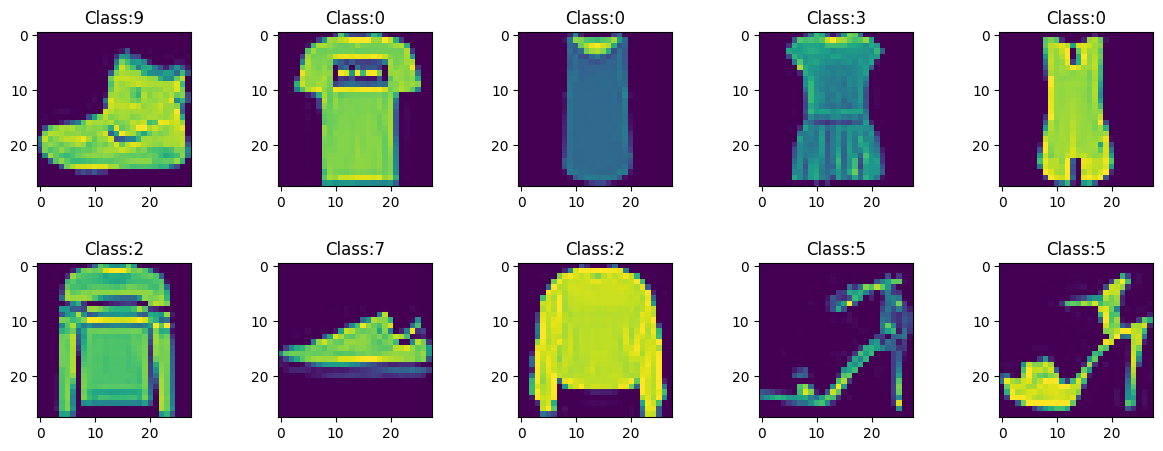

In [16]:
#Data visualization
fig, axes = plt.subplots(nrows = 2, ncols =5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28,28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

Xây dựng mô hình học ANN

In [19]:
#initial ANN model
from keras.layers import Input
fashion_model = Sequential()
#add input layer and first hidden layer
fashion_model.add(Input(shape=(X_train.shape[1],)))
fashion_model.add(Dense(units = 256, kernel_initializer='uniform', activation='relu'))
#add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
#compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#model summary
fashion_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện ANN model

In [20]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8223 - loss: 0.5048 - val_accuracy: 0.8598 - val_loss: 0.3956
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8642 - loss: 0.3756 - val_accuracy: 0.8680 - val_loss: 0.3664
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8786 - loss: 0.3335 - val_accuracy: 0.8697 - val_loss: 0.3576
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8883 - loss: 0.3060 - val_accuracy: 0.8815 - val_loss: 0.3402
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8930 - loss: 0.2902 - val_accuracy: 0.8827 - val_loss: 0.3250
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8995 - loss: 0.2719 - val_accuracy: 0.8835 - val_loss: 0.3301
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9037 - loss: 0.2605 - val_accuracy: 0.8843 - val_loss: 0.3167
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9086 - loss: 0.2

Đánh giá ANN model

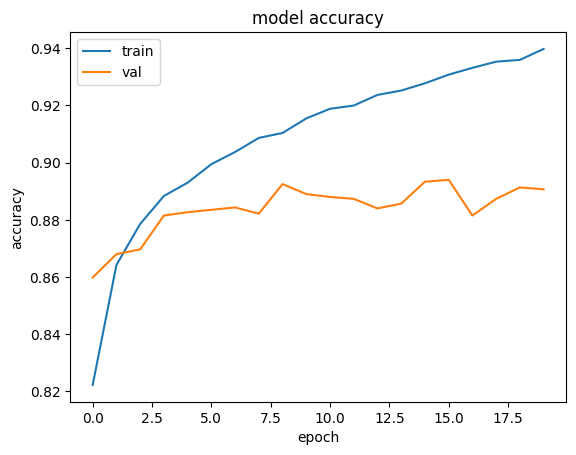

In [21]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

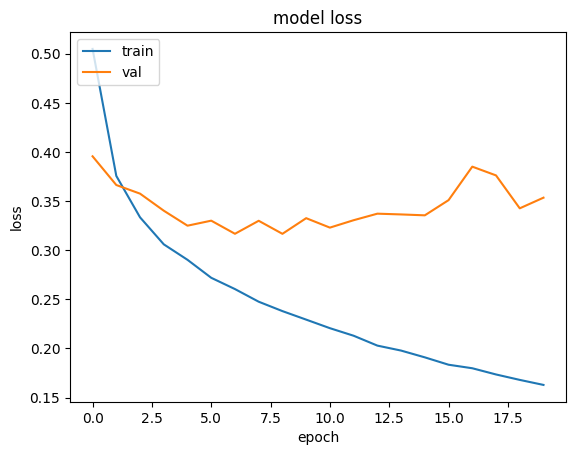

In [22]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Dự án ảnh mới

In [24]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


Đọc tập dữ liệu từ file

In [27]:
mnist_train_path='/content/sample_data/mnist_train_small.csv'
mnist_test_path='/content/sample_data/mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head())
print(mnist_train.shape)
print(mnist_test.head())
print(mnist_test.shape)

   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(19999, 785)
   7  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.658  0.659  0.660  \
0  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  1  0    0    0    0    0 

In [28]:
X_train = mnist_train.iloc[:,1:]
X_test = mnist_test.iloc[:,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

(19999, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [29]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] )
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_fit = model.fit(X_train, y_train, epochs = 20, verbose = 1)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8791 - loss: 1.1255
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9329 - loss: 0.2660
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9471 - loss: 0.2069
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9478 - loss: 0.2123
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9491 - loss: 0.2308
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9541 - loss: 0.1973
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9536 - loss: 0.2077
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9586 - loss: 0.2043
Epoch 9/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9647 - loss: 0.1516
Epoch 10/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9629 - loss: 0.1871
Epoch 11/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9631 - loss: 0.1886
Epoch 12/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms

In [31]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2 2


1. Đang lọc dữ liệu và huấn luyện mạng ANN chuyên biệt cho Váy, Quần, Áo...
-> Mạng ANN chuyên biệt đã huấn luyện xong!

2. Đang tải dữ liệu ảnh thực tế từ Internet và trích xuất ma trận pixel...
-> Tải thành công ảnh mẫu số 1
-> Tải thành công ảnh mẫu số 2
-> Tải thành công ảnh mẫu số 3
-> Tải thành công ảnh mẫu số 4


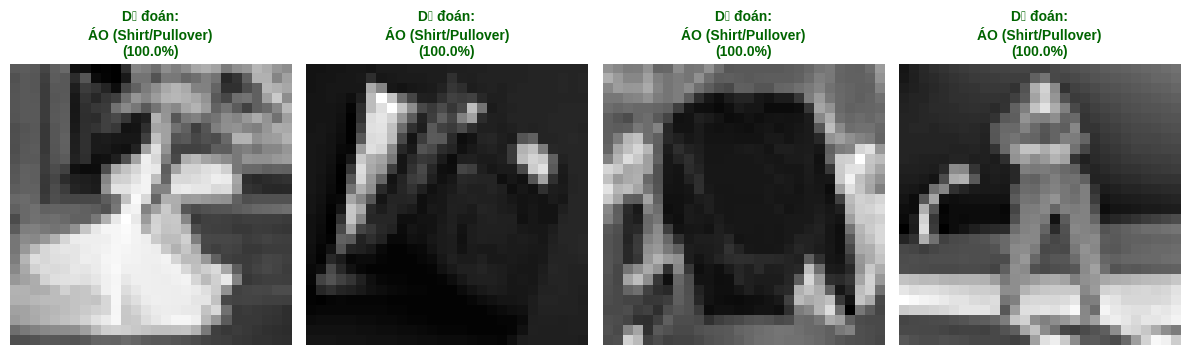

In [78]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
import io

print("1. Đang lọc dữ liệu và huấn luyện mạng ANN chuyên biệt cho Váy, Quần, Áo...")
(X_train_raw, y_train_raw), _ = tf.keras.datasets.fashion_mnist.load_data()

valid_indices = np.where((y_train_raw == 0) | (y_train_raw == 1) | (y_train_raw == 2) | (y_train_raw == 3) | (y_train_raw == 4) | (y_train_raw == 6))[0]
X_train = X_train_raw[valid_indices] / 255.0
y_train_mapped = y_train_raw[valid_indices]

y_train = np.zeros_like(y_train_mapped)
y_train[y_train_mapped == 1] = 1
y_train[y_train_mapped == 3] = 2

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=4, batch_size=128, verbose=0)
print("-> Mạng ANN chuyên biệt đã huấn luyện xong!")

target_labels = {
    0: "ÁO (Shirt/Pullover)",
    1: "QUẦN (Trouser)",
    2: "VÁY (Dress)"
}

image_urls = [
    'https://images.unsplash.com/photo-1595777457583-95e059d581b8?q=80&w=200',
    'https://images.unsplash.com/photo-1542272604-787c3835535d?q=80&w=200',
    'https://images.unsplash.com/photo-1620799140408-edc6dcb6d633?q=80&w=200',
    'https://images.unsplash.com/photo-1515886657613-9f3515b0c78f?q=80&w=200',
    'https://images.unsplash.com/photo-1582552938357-103a9f877507?q=80&w=200'
]

print("\n2. Đang tải dữ liệu ảnh thực tế từ Internet và trích xuất ma trận pixel...")
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

valid_images = []
for index, url in enumerate(image_urls):
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code == 200:
            img = Image.open(io.BytesIO(response.content)).convert('L').resize((28, 28))
            valid_images.append(img)
            print(f"-> Tải thành công ảnh mẫu số {index + 1}")
    except Exception as e:
        continue

if valid_images:
    num_images = len(valid_images)
    fig, axes = plt.subplots(1, num_images, figsize=(3 * num_images, 4))
    if num_images == 1:
        axes = [axes]

    for i, img in enumerate(valid_images):
        img_array = np.array(img)

        if np.mean(img_array) > 127:
            img_array = 255 - img_array

        img_array = img_array / 255.0
        img_tensor = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_tensor, verbose=0)[0]
        score = np.argmax(predictions)
        confidence = predictions[score] * 100

        predicted_label = target_labels.get(score, "Không xác định")

        axes[i].imshow(img_array, cmap='gray')
        axes[i].set_title(f"Dự đoán:\n{predicted_label}\n({confidence:.1f}%)", fontsize=10, fontweight='bold', color='darkgreen')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("❌ Thất bại: Không thể kết nối để nạp dữ liệu ảnh.")

Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau. 0: airpolane,
1: automobile, 2: bird, 3: cat, 4 deer, 5: dog, 6: frog, 7: horse, 8: ship, 9: truck.

In [41]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train, X_test = X_train / 255.0, X_test / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

model = tf.keras.Sequential([

    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Bắt đầu huấn luyện...")
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=0)
print(f"\nĐộ chính xác trên tập kiểm thử (Test Accuracy): {test_acc*100:.2f}%")

img_demo = X_test[0]
label_true = y_test[0][0]
img_batch = tf.expand_dims(img_demo, 0)
predictions = model.predict(img_batch, verbose=0)
label_pred = np.argmax(predictions[0])

print(f"Ảnh test số 0 - Mô hình dự đoán: {class_names[label_pred]} | Nhãn thực tế: {class_names[label_true]}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Bắt đầu huấn luyện...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.3274 - loss: 1.8547 - val_accuracy: 0.4026 - val_loss: 1.6744
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 26ms/step - accuracy: 0.3993 - loss: 1.6717 - val_accuracy: 0.4277 - val_loss: 1.5947
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.4296 - loss: 1.5933 - val_accuracy: 0.4297 - val_loss: 1.6189
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.4501 - loss: 1.5381 - val_accuracy: 0.4513 - val_loss: 1.5298
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.4648 - loss: 1.4930 - val_accuracy: 0.4499 - val_loss: 1.5266
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.4726 - loss: 1.4678 - val_accuracy: 0.4636 - val_loss: 1.5073
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.4886 - loss: 1.4344 - val_accuracy: 0.4596 - val_loss: 1.5236
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/ste

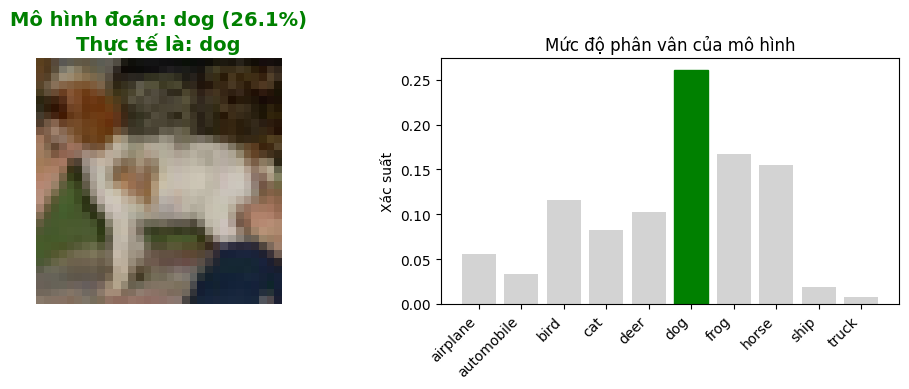

In [42]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

index = 12
img_demo = X_test[index]
label_true = y_test[index][0]
img_batch = tf.expand_dims(img_demo, 0)
predictions = model.predict(img_batch, verbose=0)
label_pred = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_demo)
plt.axis('off')
text_color = 'green' if label_pred == label_true else 'red'
plt.title(f"Mô hình đoán: {class_names[label_pred]} ({confidence:.1f}%)\nThực tế là: {class_names[label_true]}",
          color=text_color, fontsize=14, fontweight='bold')
plt.subplot(1, 2, 2)
bars = plt.bar(class_names, predictions[0], color='lightgray')
bars[label_pred].set_color('red')
bars[label_true].set_color('green')

plt.ylabel('Xác suất')
plt.title('Mức độ phân vân của mô hình')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

2. Viết chương trình cài đặt ANN để nhận dạng ảnh chữ viết số trên bộ dataset MNIST :
Label 0: Nhãn Số 0
Label 1: Nhãn Số 1
Label 2: Nhãn Số 2
Label 3: Nhãn Số 3
Label 4: Nhãn Số 4
Label 5: Nhãn Số 5
Label 6: Nhãn Số 6
Label 7: Nhãn Số 7
Label 8: Nhãn Số 8
Label 9: Nhãn Số 9

1. Đang tải và chuẩn bị dữ liệu MNIST...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
2. Đang khởi tạo mô hình ANN...
3. Bắt đầu huấn luyện...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9152 - loss: 0.2918 - val_accuracy: 0.9578 - val_loss: 0.1426
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9579 - loss: 0.1441 - val_accuracy: 0.9711 - val_loss: 0.0996
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9682 - loss: 0.1066 - val_accuracy: 0.9681 - val_loss: 0.0983
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9730 - loss: 0.0880 - val_accuracy: 0.9760 - val_loss: 0.0773
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9766 - loss: 0.0744 - val_accuracy: 0.9770 - val_loss: 0.0723

4. Đang tải ảnh kiểm thử từ: https://machinelearningmastery.com/wp-content/uploads/2019/02/sample_image.png
Tải ảnh thành công! Bắt đầu tiền xử lý...



 KẾT QUẢ: Mô hình dự đoán đây là Nhãn Số 7


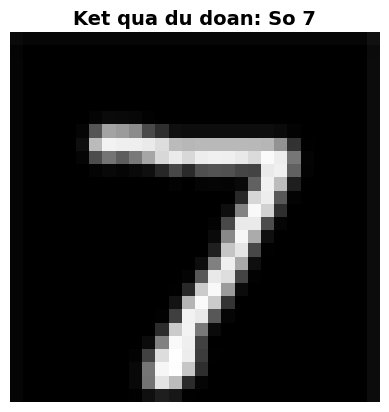

In [43]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image, ImageOps
import io
print("1. Đang tải và chuẩn bị dữ liệu MNIST...")
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train, X_test = X_train / 255.0, X_test / 255.0

print("2. Đang khởi tạo mô hình ANN...")
model = tf.keras.Sequential([

    tf.keras.layers.Flatten(input_shape=(28, 28)),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print("3. Bắt đầu huấn luyện...")
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))
image_url = "https://machinelearningmastery.com/wp-content/uploads/2019/02/sample_image.png"

print(f"\n4. Đang tải ảnh kiểm thử từ: {image_url}")
response = requests.get(image_url, headers={'User-Agent': 'Mozilla/5.0'})

if response.status_code == 200:
    print("Tải ảnh thành công! Bắt đầu tiền xử lý...")
    img = Image.open(io.BytesIO(response.content)).convert('L')
    img = img.resize((28, 28))
    img_array = np.array(img) / 255.0
    img_tensor = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_tensor, verbose=0)
    predicted_label = np.argmax(prediction)

    print(f"\n KẾT QUẢ: Mô hình dự đoán đây là Nhãn Số {predicted_label}")

    plt.imshow(img_array, cmap='gray')
    plt.title(f"Ket qua du doan: So {predicted_label}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print(f" Không thể tải ảnh. Mã lỗi HTTP: {response.status_code}")

Bài 3: Cho đoạn mã đọc ảnh của CAT và DOG. Hãy viết chương trình cài đặt ANN để nhận dạng ảnh Cat hoặc Dog. Dữ liệu do giảng viên cung cấp.

Bài 4: Viết chương trình cài đặt ANN để dự báo thu nhập một người >50K/ năm hay <=50K/năm (nhãn cuối_ theo bộ dữ liệu adult)

In [47]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("1. Đang tải dữ liệu Adult Census Income từ UCI...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

df = pd.read_csv(url, names=columns, skipinitialspace=True, na_values='?')

df = df.dropna()

print(f" Đã tải xong! Kích thước dữ liệu: {df.shape[0]} người, {df.shape[1]} thuộc tính.")

print("\n2. Đang tiền xử lý dữ liệu...")

df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

X = df.drop('income', axis=1)
y = df['income']

X_raw = X.copy()

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\n3. Khởi tạo và huấn luyện mạng Neural Network (ANN)...")
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n Đã huấn luyện xong! Độ chính xác trên tập kiểm thử: {accuracy*100:.2f}%")

print("\n" + "="*50)
print("KIỂM TRA VỚI MỘT NGƯỜI CỤ THỂ TRONG TẬP DỮ LIỆU")
print("="*50)

sample_index = 10
original_index = X_test.index[sample_index]

person_info = X_raw.loc[original_index]
actual_income = "<=50K" if y_test.iloc[sample_index] == 0 else ">50K"

person_encoded = X_test_scaled[sample_index].reshape(1, -1)

prediction_prob = model.predict(person_encoded, verbose=0)[0][0]
predicted_income = ">50K" if prediction_prob > 0.5 else "<=50K"
confidence = prediction_prob * 100 if prediction_prob > 0.5 else (1 - prediction_prob) * 100

print(f" Thông tin nhân khẩu học của người này:")
print(f" - Tuổi: {person_info['age']}")
print(f" - Bằng cấp: {person_info['education']} (Số năm học: {person_info['education-num']})")
print(f" - Nghề nghiệp: {person_info['occupation']}")
print(f" - Giới tính: {person_info['sex']}")
print(f" - Số giờ làm việc/tuần: {person_info['hours-per-week']}")
print("-" * 30)
print(f" Thực tế thu nhập của người này là : {actual_income}")
print(f" Mô hình dự đoán thu nhập là     : {predicted_income} (Độ tự tin: {confidence:.2f}%)")
if actual_income == predicted_income:
    print("=> KẾT LUẬN: Mô hình dự đoán CHÍNH XÁC! ")
else:
    print("=> KẾT LUẬN: Mô hình dự đoán SAI. ")

1. Đang tải dữ liệu Adult Census Income từ UCI...
 Đã tải xong! Kích thước dữ liệu: 30162 người, 15 thuộc tính.

2. Đang tiền xử lý dữ liệu...

3. Khởi tạo và huấn luyện mạng Neural Network (ANN)...
Epoch 1/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8202 - loss: 0.3823 - val_accuracy: 0.8342 - val_loss: 0.3448
Epoch 2/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8425 - loss: 0.3396 - val_accuracy: 0.8429 - val_loss: 0.3326
Epoch 3/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8473 - loss: 0.3285 - val_accuracy: 0.8413 - val_loss: 0.3311
Epoch 4/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8502 - loss: 0.3225 - val_accuracy: 0.8433 - val_loss: 0.3272
Epoch 5/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8524 - loss: 0.3180 - val_accuracy: 0.8421 - val_loss: 0.3246
Epoch 6/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8549 - loss: 0.3130 - val_accuracy: 0.8475 - val_loss: 0.3221
Epoch 7/10
679/679 ━━━━━━━━━━━━


 Đã huấn luyện xong! Độ chính xác trên tập kiểm thử: 85.35%

KIỂM TRA VỚI MỘT NGƯỜI CỤ THỂ TRONG TẬP DỮ LIỆU
 Thông tin nhân khẩu học của người này:
 - Tuổi: 22
 - Bằng cấp: HS-grad (Số năm học: 9)
 - Nghề nghiệp: Exec-managerial
 - Giới tính: Female
 - Số giờ làm việc/tuần: 40
------------------------------
 Thực tế thu nhập của người này là : <=50K
 Mô hình dự đoán thu nhập là     : <=50K (Độ tự tin: 99.80%)
=> KẾT LUẬN: Mô hình dự đoán CHÍNH XÁC! 


Bài 5: Viết chương trình cài đặt ANN để dự báo việc đánh giá chất lượng xe ô tô (nhãn cuối) từ bộ dữ liệu car.

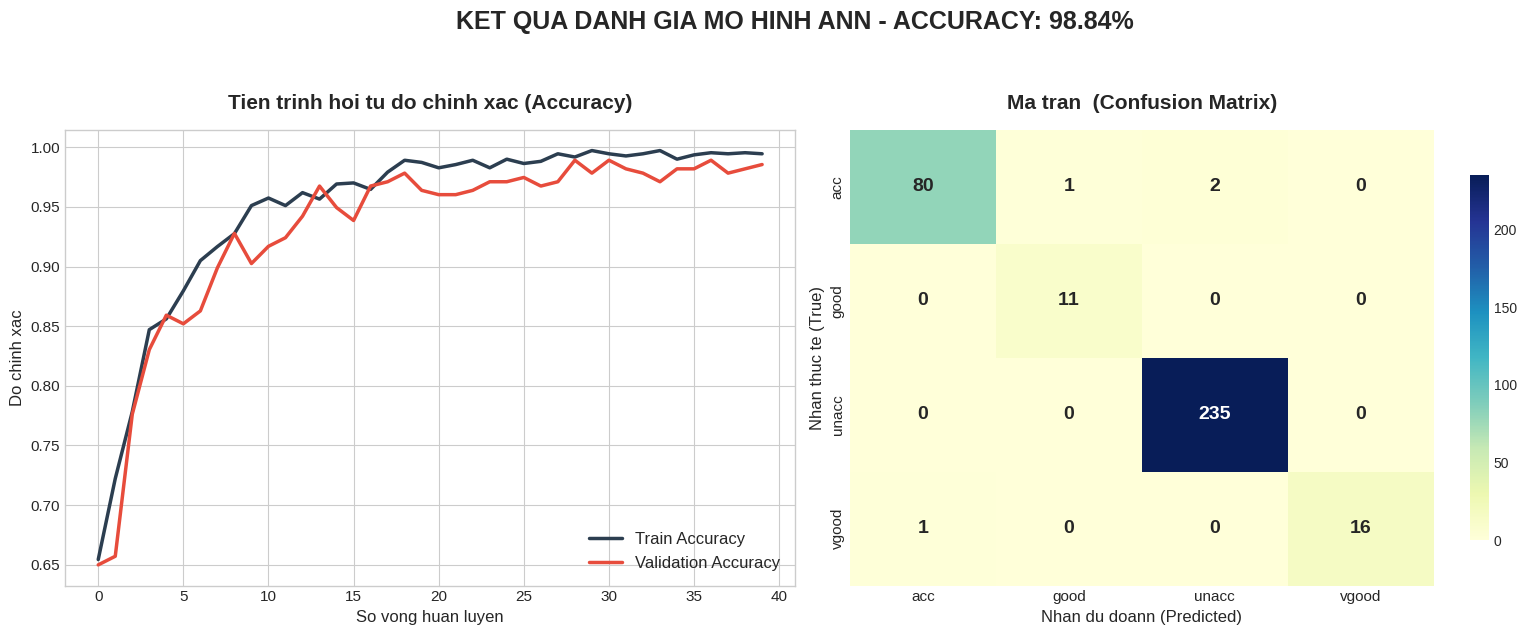

ĐO CHINH XAC TREN TAP KIEM THU : 98.84%
BAO CAO CHI TIET (CLASSIFICATION REPORT):
              precision    recall  f1-score   support

         acc       0.99      0.96      0.98        83
        good       0.92      1.00      0.96        11
       unacc       0.99      1.00      1.00       235
       vgood       1.00      0.94      0.97        17

    accuracy                           0.99       346
   macro avg       0.97      0.98      0.97       346
weighted avg       0.99      0.99      0.99       346



In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
cols = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(url, names=cols)

X = df.drop('class', axis=1)
y = df['class']

X_encoded = pd.get_dummies(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = tf.keras.utils.to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_categorical, test_size=0.2, random_state=42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=40, batch_size=32, validation_split=0.2, verbose=0)

loss, acc = model.evaluate(X_test, y_test, verbose=0)

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2.5, color='#2c3e50')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2.5, color='#e74c3c')
axes[0].set_title('Tien trinh hoi tu do chinh xac (Accuracy)', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('So vong huan luyen', fontsize=12)
axes[0].set_ylabel('Do chinh xac', fontsize=12)
axes[0].legend(fontsize=12, loc='lower right')
axes[0].tick_params(axis='both', which='major', labelsize=11)

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_,
            annot_kws={"size": 14, "weight": "bold"}, cbar_kws={'shrink': 0.8})
axes[1].set_title('Ma tran  (Confusion Matrix)', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('Nhan du doann (Predicted)', fontsize=12)
axes[1].set_ylabel('Nhan thuc te (True)', fontsize=12)
axes[1].tick_params(axis='both', which='major', labelsize=11)

plt.suptitle(f'KET QUA DANH GIA MO HINH ANN - ACCURACY: {acc*100:.2f}%', fontsize=18, fontweight='heavy', y=1.05)
plt.tight_layout()
plt.show()

print("="*60)
print(f"ĐO CHINH XAC TREN TAP KIEM THU : {acc*100:.2f}%")
print("="*60)
print("BAO CAO CHI TIET (CLASSIFICATION REPORT):")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

1. Đang huan luen ANN
-> Hoàn tất huấn luyện mô hình ANN.

2. Đang tai kien truc thi giac may tinh
3. Đang tai.

4. Đang anh xa thong so ky thuat xe de danh gia

5. TRUC QUAN HOA ...


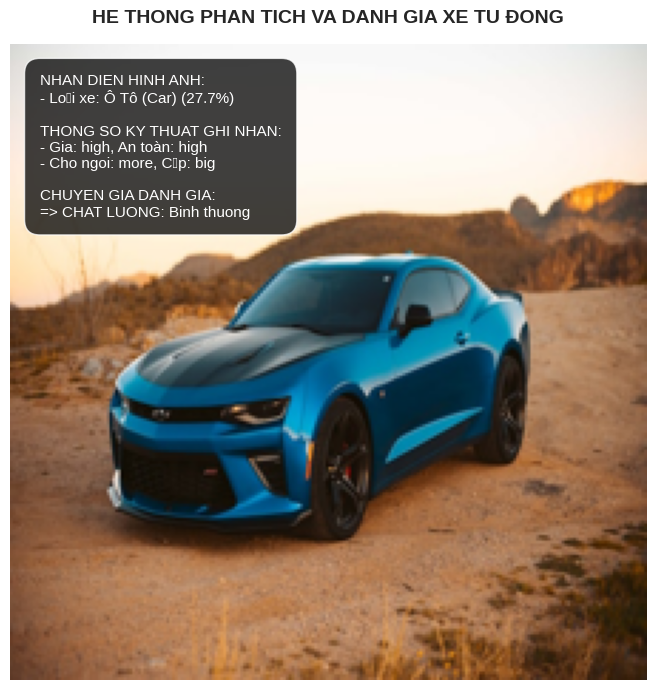

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import requests
from PIL import Image
import io
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
cols = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv(url, names=cols)

X = df.drop('class', axis=1)
y = df['class']

X_encoded = pd.get_dummies(X).astype(int)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = tf.keras.utils.to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_categorical, test_size=0.2, random_state=42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("1. Đang huan luen ANN")
history = model.fit(X_train, y_train, epochs=40, batch_size=32, validation_split=0.2, verbose=0)
print("-> Hoàn tất huấn luyện mô hình ANN.")

print("\n2. Đang tai kien truc thi giac may tinh")
image_model = MobileNetV2(weights='imagenet')

img_url = "https://images.unsplash.com/photo-1552519507-da3b142c6e3d?q=80&w=640"

print("3. Đang tai.")
response = requests.get(img_url, headers={'User-Agent': 'Mozilla/5.0'})
img = Image.open(io.BytesIO(response.content)).resize((224, 224))

img_array = np.array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)

preds = image_model.predict(img_preprocessed, verbose=0)
top_predictions = decode_predictions(preds, top=3)[0]

vehicle_type = "Khong xác đinh"
confidence = 0
for predId, name, prob in top_predictions:
    name_lower = name.lower()
    if any(keyword in name_lower for keyword in ['car', 'cab', 'jeep', 'minivan', 'suv', 'wagon', 'sports_car']):
        vehicle_type = "Ô Tô (Car)"
        confidence = prob * 100
        break
    elif any(keyword in name_lower for keyword in ['motor', 'moped', 'scooter', 'motorcycle']):
        vehicle_type = "Xe May (Motorcycle)"
        confidence = prob * 100
        break

print("\n4. Đang anh xa thong so ky thuat xe de danh gia")
car_specs = {
    'buying': ['high'],
    'maint': ['med'],
    'doors': ['4'],
    'persons': ['more'],
    'lug_boot': ['big'],
    'safety': ['high']
}

spec_df = pd.DataFrame(car_specs)
spec_encoded = pd.get_dummies(spec_df).reindex(columns=X_encoded.columns, fill_value=0).astype(int)

quality_pred = model.predict(spec_encoded, verbose=0)
quality_index = np.argmax(quality_pred)
quality_label = le.inverse_transform([quality_index])[0]

quality_dict = {
    'unacc': 'Te',
    'acc': 'Binh thuong',
    'good': 'Tot',
    'vgood': 'Rat tot (Xuat sac)'
}
final_quality = quality_dict.get(quality_label, quality_label)

print("\n5. TRUC QUAN HOA ...")
plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis('off')

result_text = (
    f"NHAN DIEN HINH ANH:\n"
    f"- Loại xe: {vehicle_type} ({confidence:.1f}%)\n\n"
    f"THONG SO KY THUAT GHI NHAN:\n"
    f"- Gia: {car_specs['buying'][0]}, An toàn: {car_specs['safety'][0]}\n"
    f"- Cho ngoi: {car_specs['persons'][0]}, Cốp: {car_specs['lug_boot'][0]}\n\n"
    f"CHUYEN GIA DANH GIA:\n"
    f"=> CHAT LUONG: {final_quality}"
)

plt.text(10, 10, result_text, fontsize=11, color='white',
         bbox=dict(facecolor='black', alpha=0.75, edgecolor='white', boxstyle='round,pad=1'),
         verticalalignment='top')

plt.title("HE THONG PHAN TICH VA DANH GIA XE TU ĐONG", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()